In [ ]:
import time
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import butter, filtfilt
from numpy.lib.stride_tricks import sliding_window_view

from sklearn.preprocessing import StandardScaler
from sklearn.mixture import GaussianMixture
from sklearn.metrics import ConfusionMatrixDisplay, classification_report, accuracy_score
import tensorflow as tf
from tensorflow.keras import models, layers, optimizers, regularizers

np.random.seed(42)
tf.random.set_seed(42)

NOISE_FACTOR = 0.05
SCALE_RANGE = (0.8, 1.2) # 1 - 100%, 0.8 80%, 1.2 120%, +20% ou -20%
N_AUGMENTS = 2

BATCH_SIZE = 64
EPOCHS = 100

def build_model(input_length, n_classes):
    model = models.Sequential([
        layers.Input(shape=(input_length, 1)), # sinal bruto
        layers.Conv1D(16, kernel_size=7, activation='relu', padding='same', kernel_regularizer=regularizers.l2(0.02)), # extrair caracteristicas
        layers.BatchNormalization(), 
        layers.MaxPooling1D(pool_size=4), # "reduzir" a qtde de caracteristicas
        layers.SpatialDropout1D(0.3),
        layers.Conv1D(32, kernel_size=5, activation='relu', padding='same', kernel_regularizer=regularizers.l2(0.02)),
        layers.BatchNormalization(),
        layers.MaxPooling1D(pool_size=4),
        layers.SpatialDropout1D(0.3),
        layers.LSTM(16, dropout=0.5),
        layers.Dense(16, activation='relu', kernel_regularizer=regularizers.l2(0.02)),
        layers.Dropout(0.5),
        layers.Dense(n_classes, activation='softmax')
    ])
    model.compile(
        optimizer=optimizers.Nadam(learning_rate=5e-4), 
        loss='sparse_categorical_crossentropy', 
        metrics=['accuracy']
    )
    return model

In [ ]:

def sliding_window(data, labels, window_size, stride):
    if data.ndim == 1:
        data = data.reshape(-1, 1)
    
    X_windows = sliding_window_view(data, (window_size, data.shape[1]))[::stride].squeeze(axis=1)
    y_windows = sliding_window_view(labels, window_size)[::stride]
    
    is_stable = np.all(y_windows == y_windows[:, [0]], axis=1)
    X_clean = X_windows[is_stable]
    y_clean = y_windows[is_stable, -1]

    return X_clean, y_clean

def process_group_data(data, csv_channel, csv_class, csv_patient, window_size, stride):
    all_X, all_y = [], []
    scalers = {}

    for p_id, p_data in data.groupby(csv_patient):
        if len(p_data) < window_size:
            continue
            
        scaler = StandardScaler()
        reshaped_data = p_data[csv_channel].values.reshape(-1, 1)
        channel_data = scaler.fit_transform(reshaped_data).flatten()
        scalers[p_id] = scaler
        
        label_data = p_data[csv_class].values
        X, y = sliding_window(channel_data, label_data, window_size, stride)

        if len(X) > 0:
            all_X.append(X)
            all_y.append(y)

    if len(all_X) == 0:
        return np.array([]), np.array([]), {}

    return np.concatenate(all_X), np.concatenate(all_y), scalers

def augment_emg(X, y, noise_factor=NOISE_FACTOR, scale_range=SCALE_RANGE, n_augments=N_AUGMENTS):
    X_aug, y_aug = [X.copy()], [y.copy()]

    # X [35000] + [35000] + [35000] = [105000]
    # y [35000] + [35000] + [35000] = [105000]
    # X + (X noise) + (X noise) + ... N_AUGMENTS
    # y + y + y + ... N_AUGMENTS
    # # TEMOS ISTO
    # ...3.3, 3.3, 3.3... # suor, umidade, grossura pele, depilagem, gordura, ...
    # ...3.3+0.001+-20%, 3.3+0.1+-20%, 3.3+0.001+-20%...

    # # OBJETIVO
    # ...3.01, 3.15, 3.25...
    # ...3.7, 3.8, 3.5...
    # ...2.9, 2.97, 2.09... 
    
    # Adição de Ruído Gaussiano + Ruído Intersujeito
    for _ in range(n_augments):
        # Ruído gaussiano
        noise = np.random.normal(0, noise_factor, X.shape)
        X_aug.append(X + noise)
        y_aug.append(y)

        # Escala aleatória
        scale = np.random.uniform(
            scale_range[0], scale_range[1],
            size=(X.shape[0], 1, 1)
        )
        X_aug.append(X * scale)
        y_aug.append(y)

    return np.concatenate(X_aug), np.concatenate(y_aug)

def plot_history(history):
    """Plota curvas de treino vs validação."""
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Loss
    axes[0].plot(history.history['loss'], label='Treino')
    axes[0].plot(history.history['val_loss'], label='Validação')
    axes[0].set_title('Loss')
    axes[0].set_xlabel('Época')
    axes[0].set_ylabel('Loss')
    axes[0].legend()
    axes[0].grid(True)

    # Accuracy
    axes[1].plot(history.history['accuracy'], label='Treino')
    axes[1].plot(history.history['val_accuracy'], label='Validação')
    axes[1].set_title('Acurácia')
    axes[1].set_xlabel('Época')
    axes[1].set_ylabel('Accuracy')
    axes[1].legend()
    axes[1].grid(True)

    plt.tight_layout()
    plt.show()

def plot_cm(y_test, y_pred, CSV_CLASSES):
    _, ax = plt.subplots(figsize=(8, 6))
    ConfusionMatrixDisplay.from_predictions(y_test, y_pred, display_labels=CSV_CLASSES, ax=ax, cmap="Blues")
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Real')
    plt.title(f"Confusion Matrix {accuracy_score(y_test, y_pred):.2%}")
    plt.show()

    # 4. Relatório completo de métricas (Precision, Recall, F1-Score)
    print("\nRelatório de Classificação:")
    print(classification_report(y_test, y_pred))

def load_tflite(model_path):
    interpreter = tf.lite.Interpreter(model_path)
    interpreter.allocate_tensors()
    input_details = interpreter.get_input_details()
    output_details = interpreter.get_output_details()

    def predict_function(data):
        input_data = np.array(data, dtype=np.float32) # formato float32
        if len(input_data.shape) == 2: # shape=(1, WINDOW_SIZE, 1)
            input_data = np.expand_dims(input_data, axis=0)
        interpreter.set_tensor(input_details[0]['index'], input_data) # define tensor de entrada
        interpreter.invoke() # inferência
        output_data = interpreter.get_tensor(output_details[0]['index'])
        return output_data
    return predict_function

In [ ]:
# CONFIGURAÇÃO
CSV_CHANNEL = 'valor'
CSV_PATIENT = 'label'
CSV_CLUSTER = 'cluster'
N_CLUSTERS = 2
TEST_PATIENT = 1
WINDOW_SIZE_MS = 150

# 1. LOAD & CONFIG
df_full = pd.read_csv('1_DADOS.csv').dropna()
SAMPLING_RATE = int(1/df_full['timestamp'].diff().mean())
WINDOW_SIZE = int((WINDOW_SIZE_MS * SAMPLING_RATE) / 1000)

In [9]:
# --- FUNÇÃO DE FILTRAGEM ---
def emg_lowpass(data, cutoff=5, fs=1000, order=4):
    nyq = 0.5 * fs
    normal_cutoff = cutoff / nyq
    b, a = butter(order, normal_cutoff, btype='low', analog=False)
    return filtfilt(b, a, data)

# 1. TRATAMENTO DO SINAL
# Retificação + Filtro Butterworth (Transforma espinhos em ondas suaves)
df_full['rect'] = df_full['valor'].abs()
df_full['env_smooth'] = emg_lowpass(df_full['rect'], cutoff=5, fs=SAMPLING_RATE)

# 2. FEATURE DE DERIVADA (Suave)
df_full['derivada'] = df_full['env_smooth'].diff().fillna(0)

# Criamos o set de treino
df_valid = df_full.dropna(subset=['env_smooth']).copy()

def scale_group(group):
    data = group.values.reshape(-1, 1)
    return StandardScaler().fit_transform(data).flatten()

X_scaled = df_valid.groupby(CSV_PATIENT)[['env_smooth', 'derivada']].transform(scale_group)
# X_scaled = StandardScaler().fit_transform(X)

# gmm = GaussianMixture(n_components=2, n_init=20, random_state=42)
lgmm = GaussianMixture(
    n_components=N_CLUSTERS, 
    covariance_type='full', 
    tol=1e-4, 
    reg_covar=1e-5,
    max_iter=200, 
    n_init=10, 
    random_state=42
)
labels = lgmm.fit_predict(X_scaled)

# 4. PÓS-PROCESSAMENTO (MODE FILTER) - O SEGREDO DO 100%
df_valid['cluster_id'] = pd.Series(labels, index=df_valid.index)
df_valid['cluster_id'] = df_valid['cluster_id'].rolling(
    window=int(SAMPLING_RATE/2),
    center=True
).apply(lambda x: x.mode()[0]).fillna(df_valid['cluster_id']) # Correção do ndarray erro

df_full['cluster'] = df_valid['cluster_id']

In [24]:
# Separar treino / teste por paciente
X_train, y_train, scalers_train = process_group_data(
    df_full[df_full[CSV_PATIENT] != TEST_PATIENT],
    CSV_CHANNEL, CSV_CLUSTER, CSV_PATIENT,
    WINDOW_SIZE, WINDOW_SIZE // 2
)
X_test, y_test, scalers_test = process_group_data(
    df_full[df_full[CSV_PATIENT] == TEST_PATIENT],
    CSV_CHANNEL, CSV_CLUSTER, CSV_PATIENT,
    WINDOW_SIZE, WINDOW_SIZE // 2
)
X_train, X_test = X_train.reshape(-1, WINDOW_SIZE, 1), X_test.reshape(-1, WINDOW_SIZE, 1) # Reshape para Conv1D (amostras, timesteps, canais)
X_train_aug, y_train_aug = augment_emg(X_train, y_train) # Data Augmentation

joblib.dump({
    **scalers_train,
    **scalers_test,
}, '2_SCALERS.pkl')

['2_SCALERS.pkl']

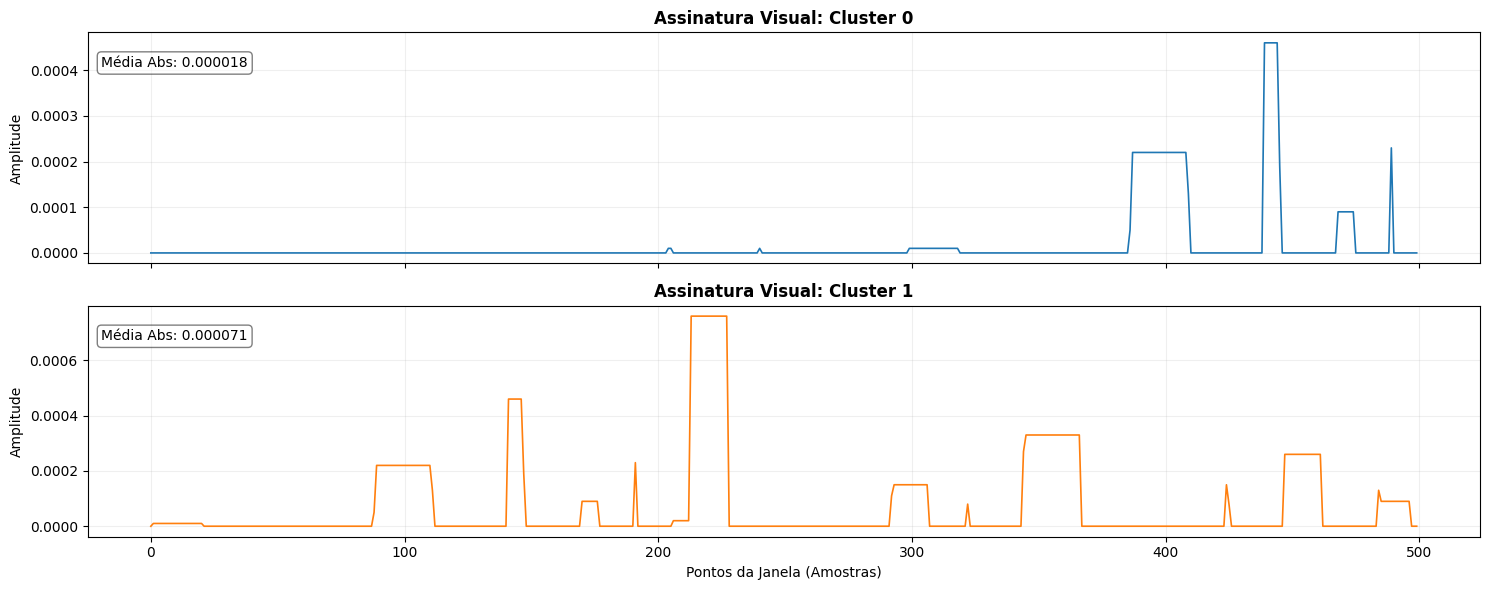

In [39]:

# Configurações
N_CLUSTERS = len(df_full['cluster'].dropna().unique())
sample_size = 500 # Tamanho da janela de tempo para visualizar
cmap = plt.get_cmap('tab10') # Paleta de cores estável

fig, axes = plt.subplots(N_CLUSTERS, 1, figsize=(15, 3 * N_CLUSTERS), sharex=True)

for i in range(N_CLUSTERS):
    indices = df_full[df_full['cluster'] == i].index
    
    start_idx = indices[0]
    data_window = df_full['valor'].iloc[start_idx : start_idx + sample_size].values
    
    # Plotagem
    axes[i].plot(data_window, color=cmap(i % 10), lw=1.2)
    axes[i].set_title(f"Assinatura Visual: Cluster {i}", fontsize=12, fontweight='bold')
    axes[i].set_ylabel("Amplitude")
    axes[i].grid(alpha=0.2)
    
    # Cálculo de métrica simples para referência no gráfico
    avg_amp = np.mean(np.abs(data_window))
    axes[i].annotate(f"Média Abs: {avg_amp:.6f}", xy=(0.01, 0.85), xycoords='axes fraction', fontsize=10, bbox=dict(boxstyle="round", fc="white", alpha=0.5))
    
axes[-1].set_xlabel("Pontos da Janela (Amostras)")
plt.tight_layout()
plt.show()

In [ ]:
X -> X_train -> X_train_aug (+2) -> BATCH_SIZE (64) (105000/64)

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_8 (Conv1D)               │ (None, 124, 16)        │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ (None, 124, 16)        │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_8 (MaxPooling1D)  │ (None, 31, 16)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout1d_8             │ (None, 31, 16)         │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_9 (Conv1D)               │ (None, 31, 32)         │         2,592 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_9           │ (None, 31, 32)         │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_9 (MaxPooling1D)  │ (None, 7, 32)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout1d_9             │ (None, 7, 32)          │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_4 (LSTM)                   │ (None, 16)             │         3,136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 16)             │           272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 2)              │            34 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,354 (24.82 KB)

 Trainable params: 6,258 (24.45 KB)

 Non-trainable params: 96 (384.00 B)

Epoch 1/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 24s 177ms/step - accuracy: 0.5812 - loss: 1.3996 - val_accuracy: 0.9444 - val_loss: 1.3134
Epoch 2/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 51ms/step - accuracy: 0.6396 - loss: 1.3230 - val_accuracy: 0.9706 - val_loss: 1.2549
Epoch 3/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 45ms/step - accuracy: 0.7396 - loss: 1.2199 - val_accuracy: 0.9477 - val_loss: 1.1961
Epoch 4/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 47ms/step - accuracy: 0.8089 - loss: 1.1343 - val_accuracy: 0.9150 - val_loss: 1.1391
Epoch 5/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 52ms/step - accuracy: 0.8455 - loss: 1.0605 - val_accuracy: 0.8725 - val_loss: 1.0853
Epoch 6/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 47ms/step - accuracy: 0.8921 - loss: 0.9768 - val_accuracy: 0.8366 - val_loss: 1.0342
Epoch 7/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 47ms/step - accuracy: 0.9198 - loss: 0.8901 - val_accuracy: 0.8170 - val_loss: 0.9878
Epoch 8/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 48ms/step - accuracy: 0.9267 - loss: 0.8289 - val_accuracy: 

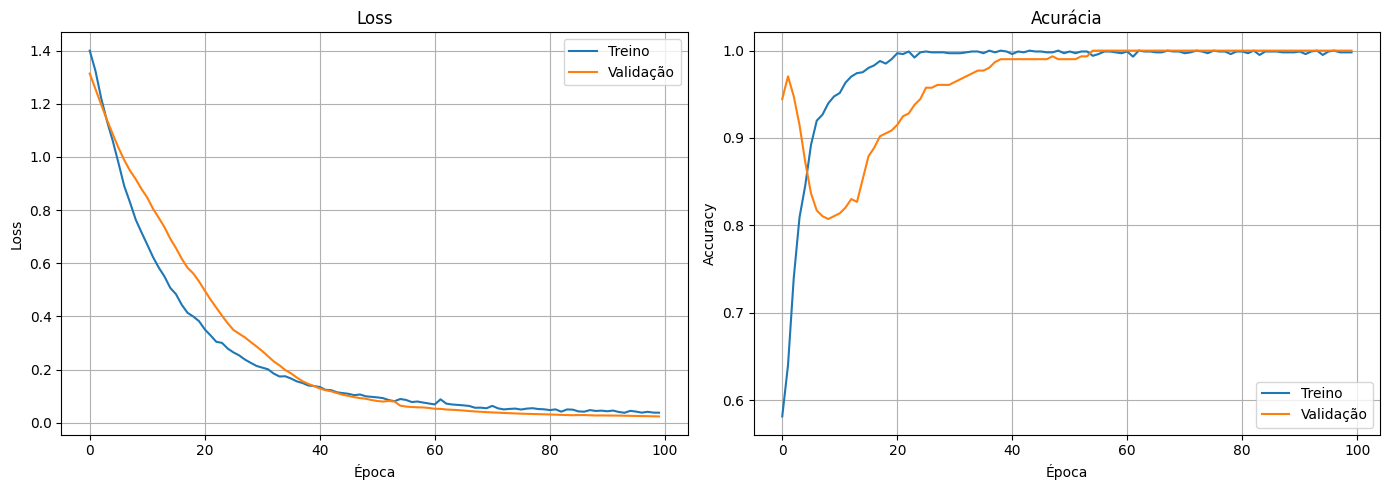

In [47]:
model = build_model(WINDOW_SIZE, N_CLUSTERS)
model.summary()

history = model.fit(
    X_train_aug, y_train_aug,
    validation_data=(X_test, y_test),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    shuffle=False,
    verbose=1
)
plot_history(history)

In [ ]:
AQUISICAO (150ms) (124 pontos -> SERIAL) -> INFERENCIA (124pontos -> LSTM -> SAÍDA/CLUSTER DO SINAL (1ms)) -> HARDWARE (?)

INFO:tensorflow:Assets written to: C:\Users\gabri\AppData\Local\Temp\tmp_hp6z5l6\assets


INFO:tensorflow:Assets written to: C:\Users\gabri\AppData\Local\Temp\tmp_hp6z5l6\assets


Saved artifact at 'C:\Users\gabri\AppData\Local\Temp\tmp_hp6z5l6'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 124, 1), dtype=tf.float32, name='keras_tensor_52')
Output Type:
  TensorSpec(shape=(None, 2), dtype=tf.float32, name=None)
Captures:
  2529587466064: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2529587467984: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2529587468368: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2529587469328: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2529587469136: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2529587468560: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2529587468944: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2529587468176: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2529587467600: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2529587470480: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2529587

c:\Users\gabri\miniconda3\envs\lab0\Lib\site-packages\tensorflow\lite\python\interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)


LATÊNCIA MÉDIA: 0.000346865032661061s


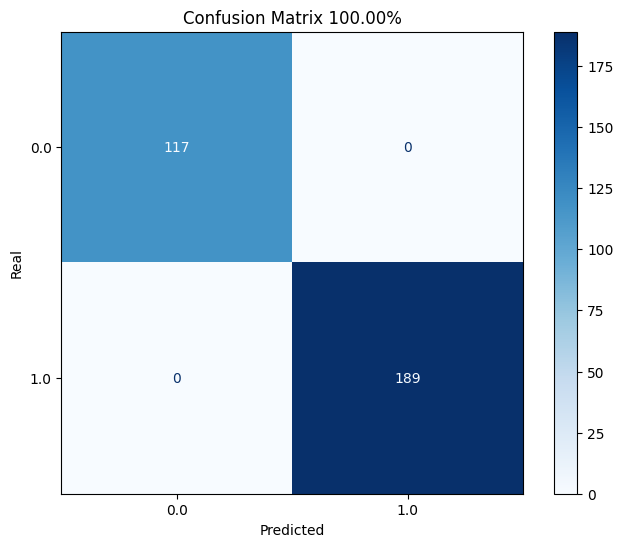


Relatório de Classificação:
              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00       117
         1.0       1.00      1.00      1.00       189

    accuracy                           1.00       306
   macro avg       1.00      1.00      1.00       306
weighted avg       1.00      1.00      1.00       306



In [48]:
converter = tf.lite.TFLiteConverter.from_keras_model(model)
converter.target_spec.supported_ops = [ # suporte para Select TF Ops (operações sem equivalente nativo no TFLite)
    tf.lite.OpsSet.TFLITE_BUILTINS, # Operações padrão TFLite
    tf.lite.OpsSet.SELECT_TF_OPS   # Operações extras do TF - RNN
]
with open('2_MODELO.tflite', 'wb') as f:
    f.write(converter.convert())

model_predict = load_tflite("2_MODELO.tflite")

inicio = time.perf_counter()
y_pred_raw = []
for i in range(len(X_test)):
    resultado = model_predict(X_test[i])
    y_pred_raw.append(resultado[0])
y_pred = np.argmax(y_pred_raw, axis=1)
fim = time.perf_counter()

print(f"LATÊNCIA MÉDIA: {(fim - inicio) / len(X_test)}s")
plot_cm(y_test, y_pred, df_full[CSV_CLUSTER].unique())

In [ ]:
# NOVO ARQUIVO -> 3_TRANSFER
# TRANFER LEARNING
# 0-MAX -> 0-1 (SCALER -> SALVA) -> LSTM